In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import linear_model
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names') # ignore this warning

In [2]:
df = pd.read_csv("house-prices(in).csv")
df

,area,price
0,1567,177067.50
1,3345,511748.20
2,3722,404096.67
3,2783,357916.31
4,2949,362409.54
...,...,...
995,3442,434336.51
996,1530,211400.14
997,2102,172513.03
998,1551,200701.84


In [3]:
df["price"] = df["price"].astype(int)# converts the type of prices from float to int
df

,area,price
0,1567,177067
1,3345,511748
2,3722,404096
3,2783,357916
4,2949,362409
...,...,...
995,3442,434336
996,1530,211400
997,2102,172513
998,1551,200701


In [4]:
df.dtypes


area     int64
price    int64
dtype: object

Text(0, 0.5, 'Price (in $)')

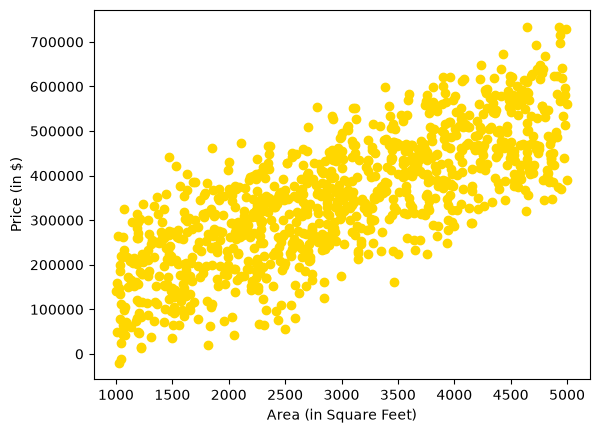

In [5]:
plt.scatter(df["area"], df["price"], color="gold")
plt.xlabel("Area (in Square Feet)")
plt.ylabel("Price (in $)")


In [6]:
reg_obj = linear_model.LinearRegression()#new object of linear regression
reg_obj.fit(df[["area"]], df["price"]) #training, model automatically finds the best line
#the independant variable X is used in 2d in the linear regression function so it's put in double brackets
#price (output) is 1d

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[96.6]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.095e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
df2 = pd.DataFrame({"area": df["area"]})
df2
#makes the area 2d b4 making the model predict to avoid the warning i talked about before 

,area
0,1567
1,3345
2,3722
3,2783
4,2949
...,...
995,3442
996,1530
997,2102
998,1551


In [8]:
predicted_arr = reg_obj.predict(df2)
print(predicted_arr[:10], end=", ")# prints ',' at the end
print("...", end=", ")
print(predicted_arr[-10:])# '-' means counting from the end, from the 10th objesct from the end to the end.


[212322.42533304 384073.7407947  420491.20194714 329785.6422067
 345820.9168786  405711.70179774 266417.32784065 360600.417028
 484342.50651416 276656.72010102], ..., [378857.44662432 212708.8174938  416723.87837965 393250.55461295
 468597.02596284 393443.75069334 208748.29784593 264002.37683584
 210776.85668996 470915.37892745]


In [9]:
m = reg_obj.coef_ # ouputs the value of slope(m)
m
#it is better to say m = reg_obj.coef[0] to get a number not an array


array([96.59804019])

In [10]:
c = reg_obj.intercept_ # outputs the value of intercept(c)
c


np.float64(60953.2963519193)

In [11]:
'''x = df2.to_numpy()'''
# coverts pandas' values to numbers ready to be used.
#i can also do this:
x = df2["area"].to_numpy()

In [12]:
# y = m * x + c
using_formula_arr = np.empty(1000)
for i in range(len(x)):
 using_formula_arr[i] = m[0] * x[i] + c #i have to say m[0] to get the coef because it's an array.
# print(m * x[i] + c, end=", ")
print(using_formula_arr[:10], end=", ")
print("...", end=", ")
print(using_formula_arr[-10:])

[212322.42533304 384073.7407947  420491.20194714 329785.6422067
 345820.9168786  405711.70179774 266417.32784065 360600.417028
 484342.50651416 276656.72010102], ..., [378857.44662432 212708.8174938  416723.87837965 393250.55461295
 468597.02596284 393443.75069334 208748.29784593 264002.37683584
 210776.85668996 470915.37892745]


In [13]:
np.array_equal(predicted_arr, using_formula_arr)#check if the predicted prices are the same as manually calculated prices

True

In [14]:
df["predicted_price"] = predicted_arr #inserting a new coulomn 'attribute
display(df)


,area,price,predicted_price
0,1567,177067,212322.425333
1,3345,511748,384073.740795
2,3722,404096,420491.201947
3,2783,357916,329785.642207
4,2949,362409,345820.916879
...,...,...,...
995,3442,434336,393443.750693
996,1530,211400,208748.297846
997,2102,172513,264002.376836
998,1551,200701,210776.856690


Text(0, 0.5, 'Price (in $)')

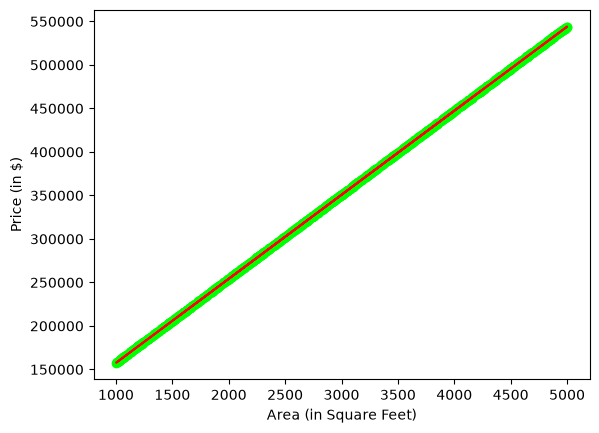

In [15]:
plt.plot(df["area"], df["predicted_price"], color="red")
plt.scatter(df["area"], using_formula_arr, color="lime")
plt.xlabel("Area (in Square Feet)")
plt.ylabel("Price (in $)")

Text(0, 0.5, 'Price (in $)')

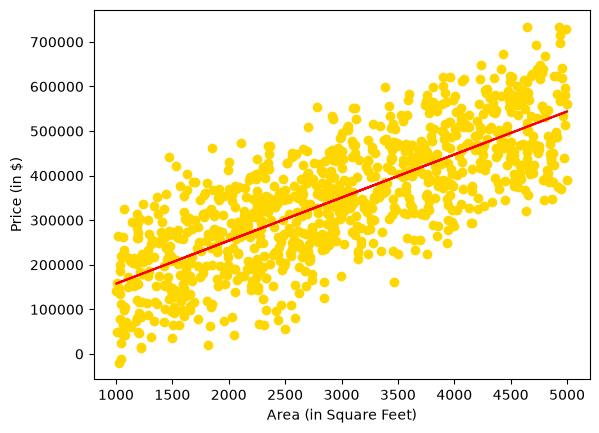

In [16]:
plt.scatter(df["area"], df["price"], color="gold")
plt.plot(df["area"], df["predicted_price"], color="red")
plt.xlabel("Area (in Square Feet)")
plt.ylabel("Price (in $)")
